In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import QuantLib as ql
import re
import tabula

In [2]:
asof_dt = datetime(2026, 7, 17)

usdjpy_spot = 162.39

usdjpy = (
    pd.read_html("./usdjpy_fwd.html")[0].iloc[:, 1:]
    .assign(
        tenor=lambda d: d["Name"].str.extract(r"USDJPY\s+(.+)\s+FWD"),
        mid=lambda d: (d["Bid"] + d["Ask"])/2,
        points=lambda d: d["mid"]/100,
    )
)
usdjpy

,Name,Bid,Ask,High,Low,Chg.,Time,tenor,mid,points
0,USDJPY ON FWD,-5.1990,-4.5230,-5.0500,-4.6500,-0.149,18/07,ON,-4.86100,-0.048610
1,USDJPY TN FWD,-1.2200,-1.2000,-1.2200,-1.2000,0.128,18/07,TN,-1.21000,-0.012100
2,USDJPY SN FWD,-1.2700,-1.2600,-1.2700,-1.2600,0.077,18/07,SN,-1.26500,-0.012650
3,USDJPY SW FWD,-8.8700,-8.8600,-8.7900,-8.8600,0.090,18/07,SW,-8.86500,-0.088650
4,USDJPY 2W FWD,-18.1900,-18.1100,-18.1200,-18.1200,-0.080,18/07,2W,-18.15000,-0.181500
5,USDJPY 3W FWD,-27.1400,-27.0600,-27.0700,-27.0600,0.190,18/07,3W,-27.10000,-0.271000
6,USDJPY 1M FWD,-42.5400,-42.4300,-42.4700,-42.4400,0.220,18/07,1M,-42.48500,-0.424850
7,USDJPY 2M FWD,-83.1100,-82.9600,-82.7900,-82.9600,-0.360,18/07,2M,-83.03500,-0.830350
8,USDJPY 3M FWD,-120.4700,-120.2300,-120.4000,-120.2900,-0.110,18/07,3M,-120.35000,-1.203500
9,USDJPY 4M FWD,-163.8600,-163.3400,-163.7700,-163.5000,-0.140,18/07,4M,-163.60000,-1.636000


In [3]:
points = usdjpy.set_index("tenor")["points"].to_dict()

usd_calendar = ql.UnitedStates(ql.UnitedStates.Settlement)
jpy_calendar = ql.Japan()
calendar = ql.JointCalendar(
    usd_calendar,
    jpy_calendar,
    ql.JoinHolidays,
)

asof = ql.Date(asof_dt.day, asof_dt.month, asof_dt.year)
tom = calendar.advance(asof, 1, ql.Days)
spot = calendar.advance(asof, 2, ql.Days)
sn = calendar.advance(spot, 1, ql.Days)

In [4]:
def to_py_date(date: ql.Date):
    return datetime(date.year(), date.month(), date.dayOfMonth())

def to_ql_date(date: datetime):
    return ql.Date(date.day, date.month, date.year)

def tenor_to_maturity_from(tenor: str, date: ql.Date):
    match = re.match(r"(\d+)([DWMY])", "1W" if tenor == "SW" else tenor)
    n = int(match.group(1))
    unit = {
        "D": ql.Days,
        "W": ql.Weeks,
        "M": ql.Months,
        "Y": ql.Years,
    }[match.group(2)]

    return calendar.advance(
        date,
        ql.Period(n, unit),
        ql.ModifiedFollowing,
        False
    )

nodes = [
    {
        "label": "TOD",
        "delivery_date": to_py_date(asof),
        "outright": usdjpy_spot - points["TN"] - points["ON"],
    },
    {
        "label": "TOM",
        "delivery_date": to_py_date(tom),
        "outright": usdjpy_spot - points["TN"],
    },
    {
        "label": "SPOT",
        "delivery_date": to_py_date(spot),
        "outright": usdjpy_spot,
    },
    {
        "label": "SN",
        "delivery_date": to_py_date(sn),
        "outright": usdjpy_spot + points["SN"],
    },
] + [
    {
        "label": tenor,
        "delivery_date": to_py_date(tenor_to_maturity_from(tenor, spot)),
        "outright": usdjpy_spot + p,
    }
    for tenor, p in points.items() if tenor not in ["ON", "TN", "SN", "SW"]
]

fwd_curve = pd.DataFrame(nodes)
fwd_curve.to_csv("usdjpy_fwd.csv", index=False)
fwd_curve

,label,delivery_date,outright
0,TOD,2026-07-17,162.450710
1,TOM,2026-07-21,162.402100
2,SPOT,2026-07-22,162.390000
3,SN,2026-07-23,162.377350
4,2W,2026-08-05,162.208500
5,3W,2026-08-12,162.119000
6,1M,2026-08-24,161.965150
7,2M,2026-09-24,161.559650
8,3M,2026-10-22,161.186500
9,4M,2026-11-24,160.754000


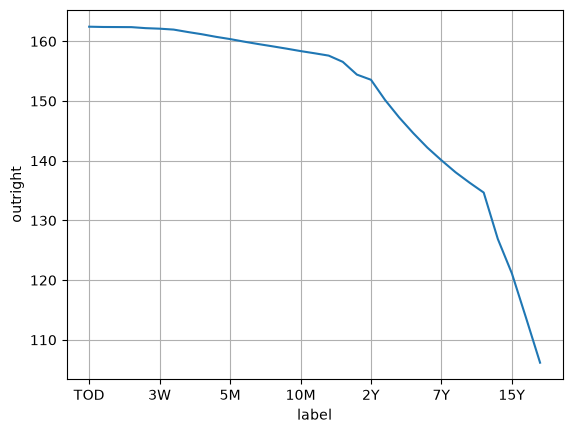

In [7]:
fwd_curve.plot(x="label", y="outright", grid=True, legend=False, ylabel="outright")
plt.show()

In [6]:
jpy_ois = (
    tabula.read_pdf(
        "SettlementRates_20260717.pdf",
        pages=1, multiple_tables=True, silent=True, force_subprocess=True
    )[0].iloc[2:, :2]
    .set_axis(["tenor", "ois"], axis=1)
    .assign(
        ois=lambda d: d["ois"].apply(pd.to_numeric),
        maturity=lambda d: d["tenor"].apply(
            lambda tenor: to_py_date(tenor_to_maturity_from(tenor, to_ql_date(asof_dt)))
        ),
    )
)

coupon_dates = [to_py_date(calendar.advance(asof, i, ql.Months)) for i in range(6, 40 * 12 + 1, 6)]
discount_factors = []

def interp_discount_factor(deal_date: datetime):
    x = np.array([r["maturity"].toordinal() for r in discount_factors])
    y = np.log([r["discount_factor"] for r in discount_factors])
    xt = float(deal_date.toordinal())

    return float(np.exp(np.interp(xt, x, y)))

day_count = ql.Actual365Fixed()
def year_frac(maturity: datetime, start: datetime=asof_dt):
    return day_count.yearFraction(to_ql_date(start), to_ql_date(maturity))

for _, row in jpy_ois.iterrows():
    if to_ql_date(row["maturity"]) > calendar.advance(asof, 6, ql.Months):
        continue
        
    discount_factors.append({
        "maturity": row["maturity"], 
        "discount_factor": 1 / (1 + row["ois"] / 100 * year_frac(row["maturity"]))
    })

for _, row in jpy_ois.iterrows():
    if to_ql_date(row["maturity"]) <= calendar.advance(asof, 6, ql.Months):
        continue

    _coupon_dates = [date for date in coupon_dates if date < row["maturity"]]

    pv = 1.0
    for date in _coupon_dates:
        rs = [r for r in discount_factors if r["maturity"] == date]
        coupon_discount_factor = None
        if rs:
            coupon_discount_factor = rs[0]["discount_factor"]
        else:
            coupon_discount_factor = interp_discount_factor(date)
            discount_factors.append({"maturity": date, "discount_factor": coupon_discount_factor})

        pv -= row["ois"] / 100 / 2 * coupon_discount_factor
    discount_factors.append({
        "maturity": row["maturity"],
        "discount_factor": pv / (1 + row["ois"] / 100 * year_frac(row["maturity"], _coupon_dates[-1]))
    })

def calc_pv(row: pd.Series):
    _coupon_dates = [date for date in coupon_dates if date < row["maturity"]]

    pv = 0.0
    for date in _coupon_dates:
        df = [r for r in discount_factors if r["maturity"] == date][0]["discount_factor"]
        pv += row["ois"] / 100 / 2 * df
    pv += (
        (1.0 + row["ois"] / 100 * year_frac(row["maturity"], _coupon_dates[-1] if _coupon_dates else asof_dt))
        * [r for r in discount_factors if r["maturity"] == row["maturity"]][0]["discount_factor"]
    )
    return pv

jpy_ois = pd.merge(
    jpy_ois,
    pd.DataFrame(discount_factors),
    on="maturity",
    how="left",
)
jpy_ois.to_csv("jpy_ois.csv", index=False)

jpy_ois.assign(pv=lambda d: d.apply(calc_pv, axis=1))

,tenor,ois,maturity,discount_factor,pv
0,1D,0.97900,2026-07-21,0.999893,1.0
1,1W,0.97729,2026-07-24,0.999813,1.0
2,2W,0.97750,2026-07-31,0.999625,1.0
3,3W,0.97844,2026-08-07,0.999437,1.0
4,1M,0.97875,2026-08-17,0.999169,1.0
5,2M,0.97993,2026-09-17,0.998338,1.0
6,3M,0.99625,2026-10-19,0.997441,1.0
7,4M,1.02613,2026-11-17,0.996554,1.0
8,5M,1.04839,2026-12-17,0.995625,1.0
9,6M,1.07771,2027-01-19,0.994538,1.0
